# Assignment 07-Pedestrian Detection using OpenCV (HOG + SVM)
---

### Objective

To implement a pedestrian detection system using OpenCV's **Histogram of Oriented Gradients (HOG)** feature descriptor and a pre-trained **Support Vector Machine (SVM)** detector.

The experiment demonstrates the complete pedestrian detection pipeline, including:

- Image preprocessing
- Sobel gradient calculation
- Gradient magnitude and orientation
- HOG feature extraction
- Pre-trained HOG + SVM pedestrian detection
- Multi-scale sliding-window detection
- Intersection over Union (IoU)
- Non-Maximum Suppression (NMS)
- Visualization and result analysis

In [1]:
# ============================================================
# CELL 1 — Install Compatible OpenCV Version
# ============================================================

!pip uninstall -y opencv-python opencv-contrib-python opencv-python-headless opencv-contrib-python-headless -q

!pip install opencv-python==4.10.0.84 -q

print("OpenCV installation completed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 11.9 MB/s eta 0:00:00
OpenCV installation completed.


In [2]:
# ============================================================
# CELL 2 — Import Libraries and Verify Environment
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV version :", cv2.__version__)
print("NumPy version  :", np.__version__)

# Check HOG support
print(
    "HOGDescriptor available:",
    hasattr(cv2, "HOGDescriptor")
)

print(
    "People detector available:",
    hasattr(cv2, "HOGDescriptor_getDefaultPeopleDetector")
)

# Create HOG descriptor
hog_check = cv2.HOGDescriptor()

print("\nHOGDescriptor initialized successfully!")

print("\nDefault HOG Parameters")
print("-" * 40)
print("Detection window :", hog_check.winSize)
print("Block size       :", hog_check.blockSize)
print("Block stride     :", hog_check.blockStride)
print("Cell size        :", hog_check.cellSize)
print("Orientation bins :", hog_check.nbins)

OpenCV version : 4.10.0
NumPy version  : 2.1.3
HOGDescriptor available: True
People detector available: True

HOGDescriptor initialized successfully!

Default HOG Parameters
----------------------------------------
Detection window : (64, 128)
Block size       : (16, 16)
Block stride     : (8, 8)
Cell size        : (8, 8)
Orientation bins : 9


In [3]:
# ============================================================
# CELL 3 — Initialize HOG + Pre-Trained SVM Detector
# ============================================================

hog = cv2.HOGDescriptor()

people_detector = cv2.HOGDescriptor_getDefaultPeopleDetector()

hog.setSVMDetector(people_detector)

print("HOG + SVM pedestrian detector initialized successfully.")
print("Pre-trained OpenCV people detector loaded.")

HOG + SVM pedestrian detector initialized successfully.
Pre-trained OpenCV people detector loaded.


In [4]:
# ============================================================
# CELL 4 — Display HOG Configuration
# ============================================================

print("=" * 55)
print("HOG DESCRIPTOR CONFIGURATION")
print("=" * 55)

print(f"Detection Window : {hog.winSize}")
print(f"Block Size       : {hog.blockSize}")
print(f"Block Stride     : {hog.blockStride}")
print(f"Cell Size        : {hog.cellSize}")
print(f"Orientation Bins : {hog.nbins}")

print("=" * 55)

HOG DESCRIPTOR CONFIGURATION
Detection Window : (64, 128)
Block Size       : (16, 16)
Block Stride     : (8, 8)
Cell Size        : (8, 8)
Orientation Bins : 9


In [5]:
# ============================================================
# CELL 5 — Generate Synthetic Street Scene
# ============================================================

def make_synthetic_street_scene(
    width=480,
    height=320,
    n_people=3,
    seed=42
):
    """
    Create a simple synthetic street scene
    containing pedestrian-like silhouettes.
    """

    rng = np.random.RandomState(seed)

    # Gray background
    image = np.full(
        (height, width, 3),
        200,
        dtype=np.uint8
    )

    ground_truth_boxes = []

    for _ in range(n_people):

        # Random pedestrian dimensions
        w = rng.randint(40, 60)
        h = int(w * 2.6)

        x = rng.randint(
            0,
            max(1, width - w)
        )

        y_low = height // 4
        y_high = max(
            y_low + 1,
            height - h
        )

        y = rng.randint(
            y_low,
            y_high
        )

        # Draw body
        cv2.rectangle(
            image,
            (x, y + h // 6),
            (x + w, y + h),
            (60, 60, 60),
            -1
        )

        # Draw head
        cv2.circle(
            image,
            (
                x + w // 2,
                y + h // 8
            ),
            max(1, w // 3),
            (60, 60, 60),
            -1
        )

        ground_truth_boxes.append(
            (x, y, w, h)
        )

    return image, ground_truth_boxes


# Generate scene
frame, gt_boxes = make_synthetic_street_scene()

print("Synthetic street scene generated.")
print(
    "Number of ground-truth pedestrians:",
    len(gt_boxes)
)

Synthetic street scene generated.
Number of ground-truth pedestrians: 3


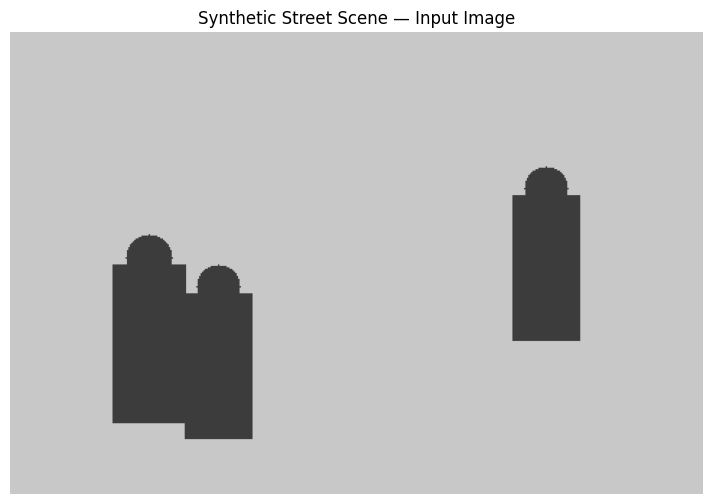

In [6]:
# ============================================================
# CELL 6 — Display Input Image
# ============================================================

plt.figure(figsize=(10, 6))

plt.imshow(
    cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Synthetic Street Scene — Input Image")
plt.axis("off")

plt.show()

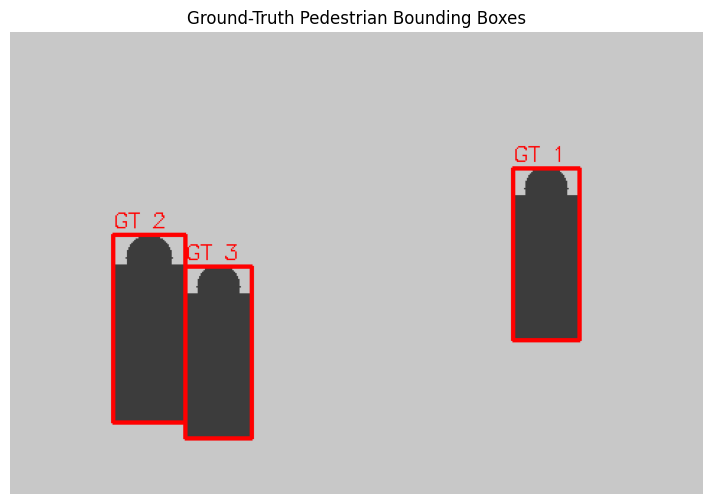

In [7]:
# ============================================================
# CELL 7 — Display Ground-Truth Bounding Boxes
# ============================================================

ground_truth_image = frame.copy()

for i, (x, y, w, h) in enumerate(gt_boxes):

    cv2.rectangle(
        ground_truth_image,
        (x, y),
        (x + w, y + h),
        (0, 0, 255),
        2
    )

    cv2.putText(
        ground_truth_image,
        f"GT {i + 1}",
        (x, max(15, y - 5)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 0, 255),
        1
    )


plt.figure(figsize=(10, 6))

plt.imshow(
    cv2.cvtColor(
        ground_truth_image,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Ground-Truth Pedestrian Bounding Boxes"
)

plt.axis("off")
plt.show()

Original image shape : (320, 480, 3)
Grayscale image shape: (320, 480)


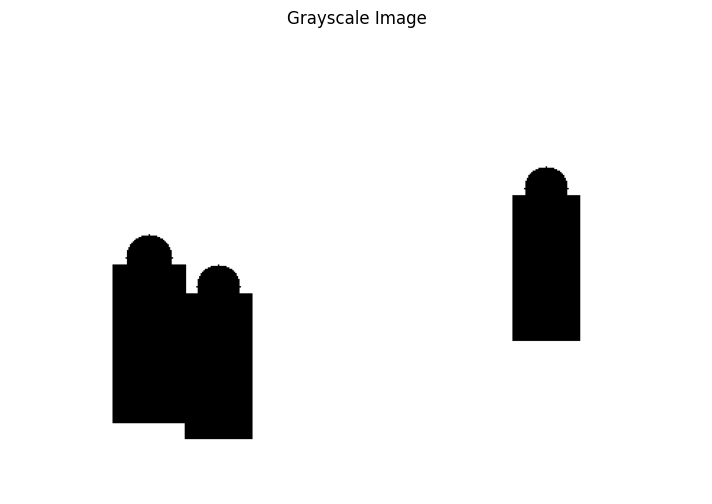

In [8]:
# ============================================================
# CELL 8 — Convert Image to Grayscale
# ============================================================

gray = cv2.cvtColor(
    frame,
    cv2.COLOR_BGR2GRAY
)

print("Original image shape :", frame.shape)
print("Grayscale image shape:", gray.shape)

plt.figure(figsize=(10, 6))

plt.imshow(
    gray,
    cmap="gray"
)

plt.title("Grayscale Image")
plt.axis("off")

plt.show()

In [9]:
# ============================================================
# CELL 9 — Calculate Sobel Gradients
# ============================================================

# Horizontal gradient
Ix = cv2.Sobel(
    gray,
    cv2.CV_64F,
    1,
    0,
    ksize=3
)

# Vertical gradient
Iy = cv2.Sobel(
    gray,
    cv2.CV_64F,
    0,
    1,
    ksize=3
)

print("Horizontal gradient (Ix) calculated.")
print("Vertical gradient (Iy) calculated.")

print("\nIx shape:", Ix.shape)
print("Iy shape:", Iy.shape)

Horizontal gradient (Ix) calculated.
Vertical gradient (Iy) calculated.

Ix shape: (320, 480)
Iy shape: (320, 480)


In [10]:
# ============================================================
# CELL 10 — Calculate Gradient Magnitude and Orientation
# ============================================================

# Gradient magnitude
gradient_magnitude = np.sqrt(
    Ix ** 2 + Iy ** 2
)

# Gradient orientation
gradient_orientation = (
    np.degrees(
        np.arctan2(Iy, Ix)
    ) + 360
) % 360

print(
    "Gradient magnitude range:",
    f"{gradient_magnitude.min():.2f}",
    "to",
    f"{gradient_magnitude.max():.2f}"
)

print(
    "Gradient orientation range:",
    f"{gradient_orientation.min():.2f}°",
    "to",
    f"{gradient_orientation.max():.2f}°"
)

Gradient magnitude range: 0.00 to 626.10
Gradient orientation range: 0.00° to 341.57°


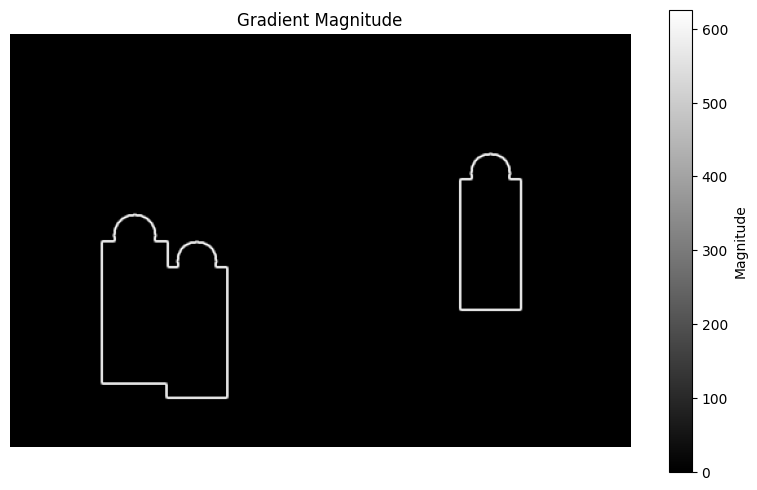

In [11]:
# ============================================================
# CELL 11 — Visualize Gradient Magnitude
# ============================================================

plt.figure(figsize=(10, 6))

plt.imshow(
    gradient_magnitude,
    cmap="gray"
)

plt.title("Gradient Magnitude")

plt.colorbar(
    label="Magnitude"
)

plt.axis("off")

plt.show()

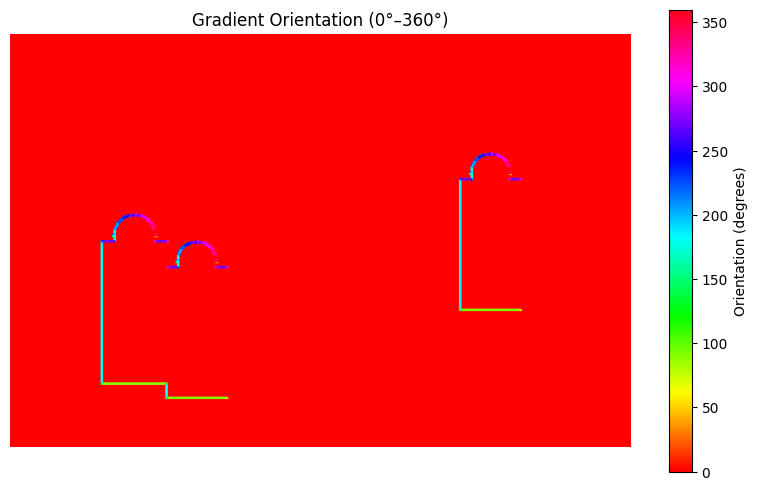

In [12]:
# ============================================================
# CELL 12 — Visualize Gradient Orientation
# ============================================================

plt.figure(figsize=(10, 6))

plt.imshow(
    gradient_orientation,
    cmap="hsv",
    vmin=0,
    vmax=360
)

plt.title(
    "Gradient Orientation (0°–360°)"
)

plt.colorbar(
    label="Orientation (degrees)"
)

plt.axis("off")

plt.show()

In [13]:
# ============================================================
# CELL 13 — Manual HOG Implementation
# ============================================================

def compute_manual_hog(
    gray_image,
    cell_size=8,
    block_size_cells=2,
    num_bins=9
):
    """
    Compute a simplified Histogram of
    Oriented Gradients (HOG) descriptor.
    """

    image = gray_image.astype(
        np.float32
    )

    # --------------------------------------------------------
    # Step 1: Calculate image gradients
    # --------------------------------------------------------

    gx = cv2.Sobel(
        image,
        cv2.CV_32F,
        1,
        0,
        ksize=1
    )

    gy = cv2.Sobel(
        image,
        cv2.CV_32F,
        0,
        1,
        ksize=1
    )

    # --------------------------------------------------------
    # Step 2: Calculate gradient magnitude
    # --------------------------------------------------------

    magnitude = cv2.magnitude(
        gx,
        gy
    )

    # --------------------------------------------------------
    # Step 3: Calculate orientation
    # HOG uses unsigned orientation: 0°–180°
    # --------------------------------------------------------

    angle = cv2.phase(
        gx,
        gy,
        angleInDegrees=True
    ) % 180

    height, width = image.shape

    # Number of complete cells
    cells_y = height // cell_size
    cells_x = width // cell_size

    # Histogram for each cell
    cell_histograms = np.zeros(
        (
            cells_y,
            cells_x,
            num_bins
        ),
        dtype=np.float32
    )

    bin_width = 180.0 / num_bins

    # --------------------------------------------------------
    # Step 4: Create orientation histogram per cell
    # --------------------------------------------------------

    for cy in range(cells_y):

        for cx in range(cells_x):

            y1 = cy * cell_size
            y2 = (cy + 1) * cell_size

            x1 = cx * cell_size
            x2 = (cx + 1) * cell_size

            cell_mag = magnitude[
                y1:y2,
                x1:x2
            ]

            cell_angle = angle[
                y1:y2,
                x1:x2
            ]

            for pixel_mag, pixel_angle in zip(
                cell_mag.ravel(),
                cell_angle.ravel()
            ):

                bin_index = int(
                    pixel_angle // bin_width
                )

                bin_index = min(
                    bin_index,
                    num_bins - 1
                )

                cell_histograms[
                    cy,
                    cx,
                    bin_index
                ] += pixel_mag

    # --------------------------------------------------------
    # Step 5: Block-level L2 normalization
    # --------------------------------------------------------

    block_features = []

    for y in range(
        cells_y - block_size_cells + 1
    ):

        for x in range(
            cells_x - block_size_cells + 1
        ):

            block = cell_histograms[
                y:y + block_size_cells,
                x:x + block_size_cells,
                :
            ]

            vector = block.ravel()

            norm = np.sqrt(
                np.sum(vector ** 2)
                + 1e-6
            )

            normalized_vector = (
                vector / norm
            )

            block_features.append(
                normalized_vector
            )

    if not block_features:
        return np.array(
            [],
            dtype=np.float32
        )

    return np.concatenate(
        block_features
    )

In [14]:
# ============================================================
# CELL 14 — Compute Manual HOG Descriptor
# ============================================================

# Resize image for HOG demonstration
hog_demo_image = cv2.resize(
    gray,
    (320, 240)
)

manual_hog_features = compute_manual_hog(
    hog_demo_image,
    cell_size=8,
    block_size_cells=2,
    num_bins=9
)

print(
    "Manual HOG descriptor computed successfully."
)

print(
    "Feature vector length:",
    len(manual_hog_features)
)

if len(manual_hog_features) > 0:

    print(
        "Minimum feature value:",
        f"{manual_hog_features.min():.6f}"
    )

    print(
        "Maximum feature value:",
        f"{manual_hog_features.max():.6f}"
    )

Manual HOG descriptor computed successfully.
Feature vector length: 40716
Minimum feature value: 0.000000
Maximum feature value: 1.000000


In [15]:
# ============================================================
# CELL 15 — HOG + SVM Multi-Scale Detection
# ============================================================

rects, weights = hog.detectMultiScale(
    frame,
    winStride=(4, 4),
    padding=(8, 8),
    scale=1.05
)

print(
    "Number of detections:",
    len(rects)
)

for i, (rect, weight) in enumerate(
    zip(rects, weights)
):

    x, y, w, h = rect

    confidence = float(
        np.asarray(weight)
        .reshape(-1)[0]
    )

    print(
        f"Detection {i + 1}: "
        f"box=({x}, {y}, {w}, {h}) | "
        f"confidence={confidence:.3f}"
    )

Number of detections: 0


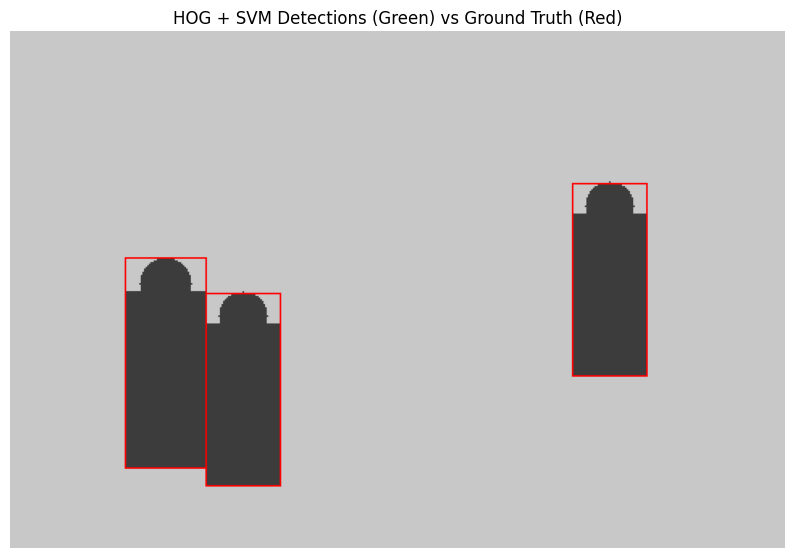

In [16]:
# ============================================================
# CELL 16 — Visualize Raw HOG + SVM Detections
# ============================================================

detected_image = frame.copy()

# ------------------------------------------------------------
# Draw HOG + SVM detections in GREEN
# ------------------------------------------------------------

for rect, weight in zip(
    rects,
    weights
):

    x, y, w, h = rect

    confidence = float(
        np.asarray(weight)
        .reshape(-1)[0]
    )

    cv2.rectangle(
        detected_image,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

    cv2.putText(
        detected_image,
        f"Detection {confidence:.2f}",
        (x, max(15, y - 5)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.45,
        (0, 255, 0),
        1
    )


# ------------------------------------------------------------
# Draw ground truth in RED
# ------------------------------------------------------------

for x, y, w, h in gt_boxes:

    cv2.rectangle(
        detected_image,
        (x, y),
        (x + w, y + h),
        (0, 0, 255),
        1
    )


plt.figure(figsize=(10, 7))

plt.imshow(
    cv2.cvtColor(
        detected_image,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "HOG + SVM Detections (Green) vs Ground Truth (Red)"
)

plt.axis("off")

plt.show()

In [17]:
# ============================================================
# CELL 17 — Intersection over Union (IoU)
# ============================================================

def calculate_iou(
    box_a,
    box_b
):
    """
    Calculate Intersection over Union (IoU)
    for boxes represented as:
    (x, y, width, height)
    """

    ax, ay, aw, ah = box_a
    bx, by, bw, bh = box_b

    # Bottom-right coordinates
    ax2 = ax + aw
    ay2 = ay + ah

    bx2 = bx + bw
    by2 = by + bh

    # Intersection coordinates
    ix1 = max(ax, bx)
    iy1 = max(ay, by)

    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)

    # Intersection dimensions
    intersection_width = max(
        0,
        ix2 - ix1
    )

    intersection_height = max(
        0,
        iy2 - iy1
    )

    # Intersection area
    intersection_area = (
        intersection_width
        * intersection_height
    )

    # Individual areas
    area_a = aw * ah
    area_b = bw * bh

    # Union area
    union_area = (
        area_a
        + area_b
        - intersection_area
    )

    if union_area <= 0:
        return 0.0

    return (
        intersection_area
        / union_area
    )

In [18]:
# ============================================================
# CELL 18 — Test IoU Calculation
# ============================================================

box_a = (
    100,
    100,
    100,
    200
)

box_b = (
    120,
    120,
    100,
    200
)

iou_value = calculate_iou(
    box_a,
    box_b
)

print("Box A:", box_a)
print("Box B:", box_b)

print(
    f"\nIoU = {iou_value:.4f}"
)

Box A: (100, 100, 100, 200)
Box B: (120, 120, 100, 200)

IoU = 0.5625


In [19]:
# ============================================================
# CELL 19 — Non-Maximum Suppression (NMS)
# ============================================================

def non_max_suppression(
    boxes,
    scores,
    iou_threshold=0.45
):
    """
    Perform IoU-based Non-Maximum Suppression.

    Parameters
    ----------
    boxes : list
        Bounding boxes in (x, y, w, h) format.

    scores : list
        Confidence score for each box.

    iou_threshold : float
        IoU threshold used to suppress overlapping boxes.

    Returns
    -------
    keep : list
        Indices of retained detections.
    """

    if len(boxes) == 0:
        return []

    boxes = np.asarray(
        boxes,
        dtype=np.float32
    )

    scores = np.asarray(
        scores,
        dtype=np.float32
    )

    # Sort boxes by confidence score
    order = scores.argsort()[::-1]

    keep = []

    while len(order) > 0:

        # Highest-confidence detection
        current = order[0]

        keep.append(
            current
        )

        remaining = []

        for idx in order[1:]:

            overlap = calculate_iou(
                boxes[current],
                boxes[idx]
            )

            # Retain boxes below IoU threshold
            if overlap < iou_threshold:

                remaining.append(
                    idx
                )

        order = np.asarray(
            remaining,
            dtype=int
        )

    return keep

In [20]:
# ============================================================
# CELL 20 — Apply NMS to HOG Detections
# ============================================================

boxes = [
    tuple(
        map(int, box)
    )
    for box in rects
]

scores = [
    float(
        np.asarray(weight)
        .reshape(-1)[0]
    )
    for weight in weights
]

print(
    "Detections before NMS:",
    len(boxes)
)

# Apply NMS
keep_indices = non_max_suppression(
    boxes,
    scores,
    iou_threshold=0.45
)

final_boxes = [
    boxes[i]
    for i in keep_indices
]

final_scores = [
    scores[i]
    for i in keep_indices
]

print(
    "Detections after NMS :",
    len(final_boxes)
)

Detections before NMS: 0
Detections after NMS : 0


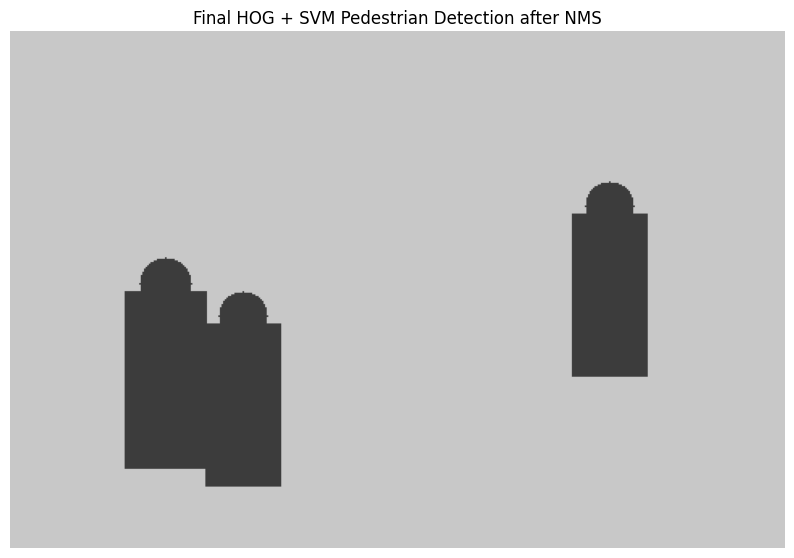

In [21]:
# ============================================================
# CELL 21 — Visualize Final Detection Results
# ============================================================

nms_image = frame.copy()

for box, score in zip(
    final_boxes,
    final_scores
):

    x, y, w, h = box

    cv2.rectangle(
        nms_image,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        3
    )

    cv2.putText(
        nms_image,
        f"Pedestrian {score:.2f}",
        (x, max(15, y - 7)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        2
    )


plt.figure(figsize=(10, 7))

plt.imshow(
    cv2.cvtColor(
        nms_image,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Final HOG + SVM Pedestrian Detection after NMS"
)

plt.axis("off")

plt.show()

In [22]:
# ============================================================
# CELL 22 — Independent NMS Demonstration
# ============================================================

demo_boxes = [
    (100, 80, 80, 180),
    (105, 85, 80, 180),
    (300, 90, 70, 170),
    (305, 95, 70, 170),
    (430, 100, 60, 160)
]

demo_scores = [
    0.92,
    0.61,
    0.88,
    0.55,
    0.79
]

demo_keep = non_max_suppression(
    demo_boxes,
    demo_scores,
    iou_threshold=0.45
)

print(
    "Sample detections before NMS:",
    len(demo_boxes)
)

print(
    "Sample detections after NMS:",
    len(demo_keep)
)

print("\nRetained detections:")

for idx in demo_keep:

    print(
        f"Box {idx + 1}: "
        f"{demo_boxes[idx]} | "
        f"Confidence = {demo_scores[idx]:.2f}"
    )

Sample detections before NMS: 5
Sample detections after NMS: 3

Retained detections:
Box 1: (100, 80, 80, 180) | Confidence = 0.92
Box 3: (300, 90, 70, 170) | Confidence = 0.88
Box 5: (430, 100, 60, 160) | Confidence = 0.79


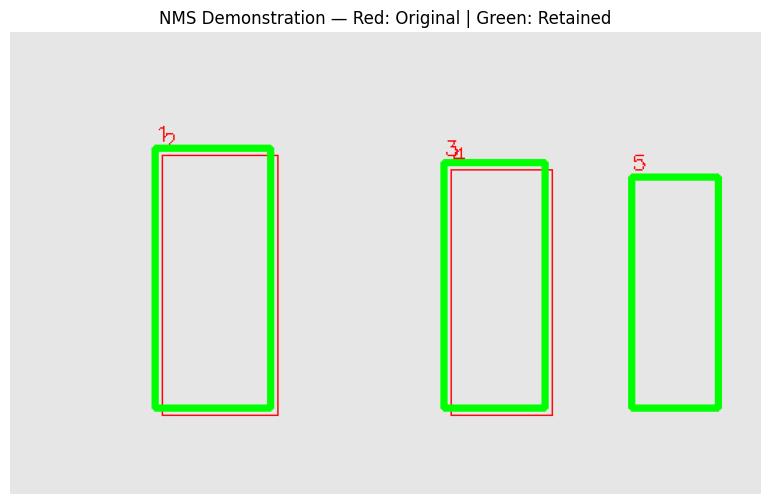

In [23]:
# ============================================================
# CELL 23 — Visualize NMS Demonstration
# ============================================================

nms_demo_image = np.full(
    (320, 520, 3),
    230,
    dtype=np.uint8
)

# Draw all original boxes in RED
for i, box in enumerate(demo_boxes):

    x, y, w, h = box

    cv2.rectangle(
        nms_demo_image,
        (x, y),
        (x + w, y + h),
        (0, 0, 255),
        1
    )

    cv2.putText(
        nms_demo_image,
        f"{i + 1}",
        (x, y - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 0, 255),
        1
    )


# Draw retained boxes in GREEN
for idx in demo_keep:

    x, y, w, h = demo_boxes[idx]

    cv2.rectangle(
        nms_demo_image,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        3
    )


plt.figure(figsize=(11, 6))

plt.imshow(
    cv2.cvtColor(
        nms_demo_image,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "NMS Demonstration — Red: Original | Green: Retained"
)

plt.axis("off")

plt.show()

In [24]:
# ============================================================
# CELL 24 — Ground Truth vs Detection IoU Analysis
# ============================================================

if len(final_boxes) == 0:

    print(
        "No HOG + SVM detections were produced "
        "on the synthetic scene."
    )

    print(
        "\nThis is expected because the synthetic "
        "pedestrians are simple geometric silhouettes, "
        "while the pre-trained OpenCV detector is trained "
        "on real pedestrian appearance patterns."
    )

else:

    print(
        "IoU analysis between final detections "
        "and ground-truth boxes:\n"
    )

    for det_index, det_box in enumerate(
        final_boxes
    ):

        best_iou = 0.0
        best_gt_index = None

        for gt_index, gt_box in enumerate(
            gt_boxes
        ):

            current_iou = calculate_iou(
                det_box,
                gt_box
            )

            if current_iou > best_iou:

                best_iou = current_iou
                best_gt_index = gt_index

        if best_gt_index is not None:

            print(
                f"Detection {det_index + 1}: "
                f"Best GT = {best_gt_index + 1}, "
                f"IoU = {best_iou:.4f}"
            )

No HOG + SVM detections were produced on the synthetic scene.

This is expected because the synthetic pedestrians are simple geometric silhouettes, while the pre-trained OpenCV detector is trained on real pedestrian appearance patterns.


In [25]:
# ============================================================
# CELL 28 — Final Experiment Summary
# ============================================================

print("=" * 70)

print(
    "TATA TECHNOLOGIES – TECHPULSE FY-26"
)

print(
    "APPLIED AI & ML – ASSIGNMENT 07"
)

print(
    "PEDESTRIAN DETECTION USING OPENCV HOG + SVM"
)

print("=" * 70)

print("\nHOG Configuration")
print("-" * 70)

print("Cell Size          : 8 × 8")
print("Block Size         : 16 × 16")
print("Block Stride       : 8 × 8")
print("Orientation Bins   : 9")
print("Normalization      : L2")
print("Detection Window   : 64 × 128")

print("\nDetection Configuration")
print("-" * 70)

print("Window Stride      : (4, 4)")
print("Padding            : (8, 8)")
print("Scale Factor       : 1.05")

print("\nNMS Configuration")
print("-" * 70)

print("IoU Threshold      : 0.45")

print("\nResults")
print("-" * 70)

print(
    "Raw HOG + SVM detections   :",
    len(rects)
)

print(
    "Final detections after NMS :",
    len(final_boxes)
)

print("\n" + "=" * 70)
print("Experiment completed successfully.")
print("=" * 70)

TATA TECHNOLOGIES – TECHPULSE FY-26
APPLIED AI & ML – ASSIGNMENT 07
PEDESTRIAN DETECTION USING OPENCV HOG + SVM

HOG Configuration
----------------------------------------------------------------------
Cell Size          : 8 × 8
Block Size         : 16 × 16
Block Stride       : 8 × 8
Orientation Bins   : 9
Normalization      : L2
Detection Window   : 64 × 128

Detection Configuration
----------------------------------------------------------------------
Window Stride      : (4, 4)
Padding            : (8, 8)
Scale Factor       : 1.05

NMS Configuration
----------------------------------------------------------------------
IoU Threshold      : 0.45

Results
----------------------------------------------------------------------
Raw HOG + SVM detections   : 0
Final detections after NMS : 0

Experiment completed successfully.


## 13. Conclusion

This experiment provided an end-to-end understanding of classical computer vision-based pedestrian detection using **Histogram of Oriented Gradients (HOG)** and a **Support Vector Machine (SVM)**.

HOG represents local shape information through gradient orientations, while the pre-trained SVM classifies image regions as pedestrian or non-pedestrian. Multi-scale detection enables the system to search for pedestrians at different sizes, and Non-Maximum Suppression helps eliminate redundant overlapping bounding boxes.

The experiment demonstrates the relevance of HOG + SVM to applications such as:

- Advanced Driver Assistance Systems (ADAS)
- Vulnerable Road User (VRU) protection
- Autonomous Emergency Braking (AEB)
- Edge-based computer vision systems

Although modern deep-learning detectors are widely used in practical systems, HOG + SVM provides a useful foundation for understanding the fundamental concepts behind object detection.